skt/kobert-base-v1

기본적인 한국어 BERT 모델로써 준수한 성능을 가짐

그러나 pre-train 단계에서 비속어 및 대화체를 학습하지 않아 정보가 없기에 우리 데이터 특성상 성능이 나올지는 미지수

<모델>

https://huggingface.co/skt/kobert-base-v1

https://github.com/SKTBrain/KoBERT

### 데이터 전처리

#### 그루밍 대화 데이터셋 전처리

In [1]:
from google.colab import files

files.upload() # 그루밍 대화 데이터

Saving merged0_수정본.csv to merged0_수정본.csv


{'merged0_수정본.csv': b'id,is_offender,text\r\n0014c1b4278df4bf8ea8a20b7abdb13c,TRUE,\xbe\xc8\xb3\xe7!\r\n0014c1b4278df4bf8ea8a20b7abdb13c,FALSE,\xbe\xc8\xb3\xe7!\r\n0014c1b4278df4bf8ea8a20b7abdb13c,TRUE,\xc0\xdf \xc1\xf6\xb3\xc2\xbe\xee?\r\n0014c1b4278df4bf8ea8a20b7abdb13c,FALSE,\xbe\xee\xb5\xf0 \xb4\xd9\xb3\xe0\xbf\xd4\xbe\xee?\r\n0014c1b4278df4bf8ea8a20b7abdb13c,FALSE,\xb1\xa6\xc2\xfa\xbe\xc6?\r\n0014c1b4278df4bf8ea8a20b7abdb13c,TRUE,\xc4\xa3\xb1\xb8\xb6\xfb \xc0\xe1\xb1\xf1 \xb3\xaa\xb0\xac\xb4\xd9 \xbf\xd4\xbe\xee.\r\n0014c1b4278df4bf8ea8a20b7abdb13c,FALSE,\xbf\xc0\xc4\xc9\xc0\xcc.\r\n0014c1b4278df4bf8ea8a20b7abdb13c,TRUE,\xb3\xaa \xba\xb8\xb0\xed \xbd\xcd\xbe\xfa\xbe\xee?\r\n0014c1b4278df4bf8ea8a20b7abdb13c,FALSE,\xc0\xc0.\r\n0014c1b4278df4bf8ea8a20b7abdb13c,TRUE,\xb1\xd7 \xbb\xe7\xc1\xf8 \xbb\xf5\xb7\xce \xc2\xef\xc0\xba \xb0\xc5\xbe\xdf?\r\n0014c1b4278df4bf8ea8a20b7abdb13c,FALSE,\xb1\xd7\xb3\xc9 \xb1\xe2\xb4\xd9\xb8\xae\xb0\xed \xc0\xd6\xbe\xfa\xbe\xee.\r\n0014c1b4278df4bf8ea8a20

In [56]:
import pandas as pd

df = pd.read_csv('/content/merged0_수정본.csv', encoding='cp949')
df.head()

,id,is_offender,text
0,0014c1b4278df4bf8ea8a20b7abdb13c,True,안녕!
1,0014c1b4278df4bf8ea8a20b7abdb13c,False,안녕!
2,0014c1b4278df4bf8ea8a20b7abdb13c,True,잘 지냈어?
3,0014c1b4278df4bf8ea8a20b7abdb13c,False,어디 다녀왔어?
4,0014c1b4278df4bf8ea8a20b7abdb13c,False,괜찮아?


In [57]:
def mark_speaker(group):
    # 그룹에서 가장 먼저 나온 행의 is_offender 값(처음 말한 사람)
    first_speaker = group.iloc[0]['is_offender']

    # is_offender가 처음 말한 사람과 같으면 '0', 다르면 '1' 붙이기
    def prefix(row):
        if row['is_offender'] == first_speaker:
            return '<SPEAKER_A>' + row['text']
        else:
            return '<SPEAKER_B>' + row['text']

    group['text'] = group.apply(prefix, axis=1)
    return group

df = df.groupby('id').apply(mark_speaker).reset_index(drop=True)

<ipython-input-57-1373312952>:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('id').apply(mark_speaker).reset_index(drop=True)


In [58]:
df.head()

,id,is_offender,text
0,0014c1b4278df4bf8ea8a20b7abdb13c,True,<SPEAKER_A>안녕!
1,0014c1b4278df4bf8ea8a20b7abdb13c,False,<SPEAKER_B>안녕!
2,0014c1b4278df4bf8ea8a20b7abdb13c,True,<SPEAKER_A>잘 지냈어?
3,0014c1b4278df4bf8ea8a20b7abdb13c,False,<SPEAKER_B>어디 다녀왔어?
4,0014c1b4278df4bf8ea8a20b7abdb13c,False,<SPEAKER_B>괜찮아?


In [59]:
df.iloc[80:100]

,id,is_offender,text
80,0014c1b4278df4bf8ea8a20b7abdb13c,True,<SPEAKER_A>알티스랑 로튼 사이에 있지?
81,0014c1b4278df4bf8ea8a20b7abdb13c,False,<SPEAKER_B>대충 그렇지.
82,0014c1b4278df4bf8ea8a20b7abdb13c,True,<SPEAKER_A>알았어.
83,0014c1b4278df4bf8ea8a20b7abdb13c,True,<SPEAKER_A>전화기 줄 거야?
84,0014c1b4278df4bf8ea8a20b7abdb13c,False,<SPEAKER_B>5시 이후엔 전화 못 해.
85,0014c1b4278df4bf8ea8a20b7abdb13c,False,<SPEAKER_B>알겠지?
86,0014c1b4278df4bf8ea8a20b7abdb13c,False,<SPEAKER_B>집 전화야.
87,0034f28e003890bc5ae2cc52eb5d0759,False,<SPEAKER_A>이번 주말에 어때?
88,0034f28e003890bc5ae2cc52eb5d0759,False,<SPEAKER_A>달콤한 사람아
89,0034f28e003890bc5ae2cc52eb5d0759,True,<SPEAKER_B>안녕!


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12334 entries, 0 to 12333
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           12334 non-null  object
 1   is_offender  12334 non-null  bool  
 2   text         12334 non-null  object
dtypes: bool(1), object(2)
memory usage: 204.9+ KB


In [61]:
merged_df = df.groupby('id')['text'].apply(lambda texts: ' '.join(texts)).reset_index()

merged_df.head()

,id,text
0,0014c1b4278df4bf8ea8a20b7abdb13c,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_A>잘 지냈어...
1,0034f28e003890bc5ae2cc52eb5d0759,<SPEAKER_A>이번 주말에 어때? <SPEAKER_A>달콤한 사람아 <SPEA...
2,0063692c957229db0816e0f240d7fa0d,<SPEAKER_A>안녕! <SPEAKER_A>안녕! <SPEAKER_A>좀 늦었는...
3,0112754943158715742e77a2ed858be9,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_B>어디 갔었...
4,01956b8f45560d2d44d594f36a66f526,"<SPEAKER_A>안녕, 섹시! <SPEAKER_A>잘 지냈어? <SPEAKER_..."


In [62]:
merged_df.drop(columns=['id'], inplace=True)

In [63]:
merged_df.head()

,text
0,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_A>잘 지냈어...
1,<SPEAKER_A>이번 주말에 어때? <SPEAKER_A>달콤한 사람아 <SPEA...
2,<SPEAKER_A>안녕! <SPEAKER_A>안녕! <SPEAKER_A>좀 늦었는...
3,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_B>어디 갔었...
4,"<SPEAKER_A>안녕, 섹시! <SPEAKER_A>잘 지냈어? <SPEAKER_..."


In [64]:
merged_df['label'] = 1
merged_df.head()

,text,label
0,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_A>잘 지냈어...,1
1,<SPEAKER_A>이번 주말에 어때? <SPEAKER_A>달콤한 사람아 <SPEA...,1
2,<SPEAKER_A>안녕! <SPEAKER_A>안녕! <SPEAKER_A>좀 늦었는...,1
3,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_B>어디 갔었...,1
4,"<SPEAKER_A>안녕, 섹시! <SPEAKER_A>잘 지냈어? <SPEAKER_...",1


#### 일반 대화 데이터셋 전처리

In [65]:
files.upload() # 일반 대화 데이터

Output hidden; open in https://colab.research.google.com to view.

In [93]:
con_lst = []
with open('_con.txt', 'r', encoding='utf-8') as f:
    con_lst.append(f.read())
con_lst


['1 : 야식은 종종 먹는 편이가? 키키 2 : 키키 야식 정말 가끔 먹는 편이다 키키 1 : 키키 오 나도 근데 집에 오니 자꾸 야식을 주네? 2 : 키키 뭐라도 좀 더 먹이고 싶으신 갑다! 키키 1 : 그런가 봄 키키 진짜 배만 나오고 있네 2 : 키키 야식은 몸에 안 좋다 했다... 2 : 술도 같이 먹나 항상? 키키 1 : 맞다 키키 술도 먹다가 요샌 안 먹고 있음 2 : 키키 나도 술을 엄청 많이 줄였다 키키 1 : 오 대단하네? 키키 니가? 키키 2 : 키키 어어... 대단하다니... 나 원래 술 많이 마시진 않았어 하하 1 : 아? 키키 그래? 키키 소주파 아니었나? 키키 2 : 키키 맞지 키키 요즘 소주 못 마시겠더라 1 : 키키 바꼈노 키키 나도 소맥이 좋긴 한데 배불러 2 : 키키 응 맥주는 배부르고... 키키 술도 끊어야 한다 정말 1 : 그러니까 키키 그런데 또 음식 먹을 때 술 먹어야 하는 음식이 있어 2 : 키키 맞지 키키 그거 때문에 항상 술을 못 끊는다 키키\n--------------------------------------------------\n1 : 너 영화 완벽한 타인 본 적 있나? 키키 2 : 어 키키 그거 재밌잖아! 난 영화관 가서 봤어 1 : 키키 응응 만약 우리도 하게 되면... 너 할 수 있어? 키키 2 : 뭐, 딱히 너무 뭐가 없다 키키 해도 됨 1 : 나도 할 수 있겠지 생각했는데 괜히... 뭔가 찔려 키키 2 : 키키 왜 어떤 게? 키키 난 너무 뭐가 없다, 남친이랑도 할 수 있을 것 같은데 서로 재미 없을 듯 키키 1 : 내 인생도 별거 없어서 괜찮기는 한데... 키키 괜히 2 : 키키 그것보단 아무한테도 연락 안 오고 막 키키 1 : 키키 아... 그 생각은 못했네 키키 나 혼자 너무 심심한 거 아니가 2 : 키키 나도 마찬가지 키키 폰이 심심해... 1 : 키키 그건 그렇다... 나이 들수록 연락 오는 곳이 없다 2 : 어... 필요한 말만 하고 끝내고... 예전에는 계속 이어 나갔는데 1 : 키키 

In [94]:
con_text = con_lst[0]
split_con = [c.strip() for c in con_text.split('--------------------------------------------------') if c.strip()]


In [95]:
split_con[2]

'1 : 박보검 해군으로 입대해서 지금 진해 있잖아 2 : 아 맞아 진해 갔다고 들었어! 1 : 코로나만 아니면 진해 군항제 해서 박보검 볼 수 있었을 텐데 2 : 헐 맞네 대박이다 2 : 박보검 보고 싶어 1 : 그치? 사람 많아서 가까이는 못 봐도 기회는 있었을 텐데 2 : 박보검 군대에서도 인기 많을 듯 1 : 키키 완전 키키 1 : 남자들이 봐도 잘 생겼을 거 아냐 2 : 맞어 실제로 보면 얼굴도 작을 듯 1 : 키키 완전 아 실제로 보고프다 2 : 군복 입은 것도 완전 멋있을 듯 1 : 키키 너 진해 군항제 보러 간 적 있어? 2 : 애기 때 한번 보러 갔나 2 : 기억이 긴가민가 1 : 나 사람 많아서 이때까지 보러 안 갔었는데 2 : 커서는 본 기억이 잘 안나 2 : 사람도 많고 해서 1 : 지금은 못 보니까 넘나 아쉽다 2 : 코로나 끝나면 볼 수 있겠지? ㅠㅠ'

In [96]:
df_n = pd.DataFrame(split_con, columns=['text'])
df_n.head()

,text
0,1 : 야식은 종종 먹는 편이가? 키키 2 : 키키 야식 정말 가끔 먹는 편이다 키...
1,1 : 너 영화 완벽한 타인 본 적 있나? 키키 2 : 어 키키 그거 재밌잖아! 난...
2,1 : 박보검 해군으로 입대해서 지금 진해 있잖아 2 : 아 맞아 진해 갔다고 들었...
3,1 : 나 오늘 장 본다고 오랜만에 야외 활동 했더니 세상이 아름답더라 2 : 오늘...
4,1 : 이번에 전력난 사태가 중국 전역으로 확산되고 있다네? 2 : 그렇게 큰 땅덩...


In [97]:
df_n['label'] = 0

In [98]:
df_n.head()

,text,label
0,1 : 야식은 종종 먹는 편이가? 키키 2 : 키키 야식 정말 가끔 먹는 편이다 키...,0
1,1 : 너 영화 완벽한 타인 본 적 있나? 키키 2 : 어 키키 그거 재밌잖아! 난...,0
2,1 : 박보검 해군으로 입대해서 지금 진해 있잖아 2 : 아 맞아 진해 갔다고 들었...,0
3,1 : 나 오늘 장 본다고 오랜만에 야외 활동 했더니 세상이 아름답더라 2 : 오늘...,0
4,1 : 이번에 전력난 사태가 중국 전역으로 확산되고 있다네? 2 : 그렇게 큰 땅덩...,0


In [99]:
df_n['text'] = df_n['text'].str.replace(r'\b1\s*:\s*', '<SPEAKER_A>', regex=True)
df_n['text'] = df_n['text'].str.replace(r'\b2\s*:\s*', '<SPEAKER_B>', regex=True)

In [100]:
df_n.head()

,text,label
0,<SPEAKER_A>야식은 종종 먹는 편이가? 키키 <SPEAKER_B>키키 야식 ...,0
1,<SPEAKER_A>너 영화 완벽한 타인 본 적 있나? 키키 <SPEAKER_B>어...,0
2,<SPEAKER_A>박보검 해군으로 입대해서 지금 진해 있잖아 <SPEAKER_B>...,0
3,<SPEAKER_A>나 오늘 장 본다고 오랜만에 야외 활동 했더니 세상이 아름답더라...,0
4,<SPEAKER_A>이번에 전력난 사태가 중국 전역으로 확산되고 있다네? <SPEA...,0


#### 최종 데이터셋 병합

In [101]:
preprocessed_df = pd.concat([merged_df, df_n], ignore_index=True)

In [102]:
preprocessed_df.head()

,text,label
0,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_A>잘 지냈어...,1
1,<SPEAKER_A>이번 주말에 어때? <SPEAKER_A>달콤한 사람아 <SPEA...,1
2,<SPEAKER_A>안녕! <SPEAKER_A>안녕! <SPEAKER_A>좀 늦었는...,1
3,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_B>어디 갔었...,1
4,"<SPEAKER_A>안녕, 섹시! <SPEAKER_A>잘 지냈어? <SPEAKER_...",1


In [104]:
preprocessed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1186 non-null   object
 1   label   1186 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 18.7+ KB


In [105]:
preprocessed_df['label'].value_counts()

,count
label,
0,1000
1,186


<Axes: >

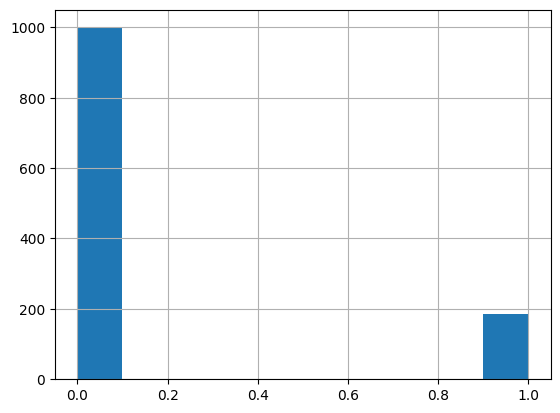

In [106]:
preprocessed_df['label'].hist()

### 모델 학습

In [ ]:
pip install git+https://git@github.com/SKTBrain/KoBERT.git@master

In [ ]:
git clone https://github.com/SKTBrain/KoBERT.git
cd KoBERT
pip install -r requirements.txt